Found 1780 images belonging to 2 classes.
Found 222 images belonging to 2 classes.
Found 224 images belonging to 2 classes.


C:\Users\Varshitha Agraharam\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.5854 - loss: 0.7323 - val_accuracy: 0.7027 - val_loss: 0.5471
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.6803 - loss: 0.5744 - val_accuracy: 0.7072 - val_loss: 0.5434
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.6933 - loss: 0.5694 - val_accuracy: 0.7207 - val_loss: 0.5490
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.7022 - loss: 0.5488 - val_accuracy: 0.7252 - val_loss: 0.5114
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.6854 - loss: 0.5679 - val_accuracy: 0.7432 - val_loss: 0.5137
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.7000 - loss: 0.5533 - val_accuracy: 0.7027 - val_loss: 0.5187
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7101 - loss: 0.5421 - val_accuracy: 0.7523 - val_loss: 0.4678
Epoch 8/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.6978 - loss: 0.5406 - val_accuracy: 0.7027 - val_


Test Accuracy: 0.75
Test Loss: 0.4817371964454651

Model saved successfully!


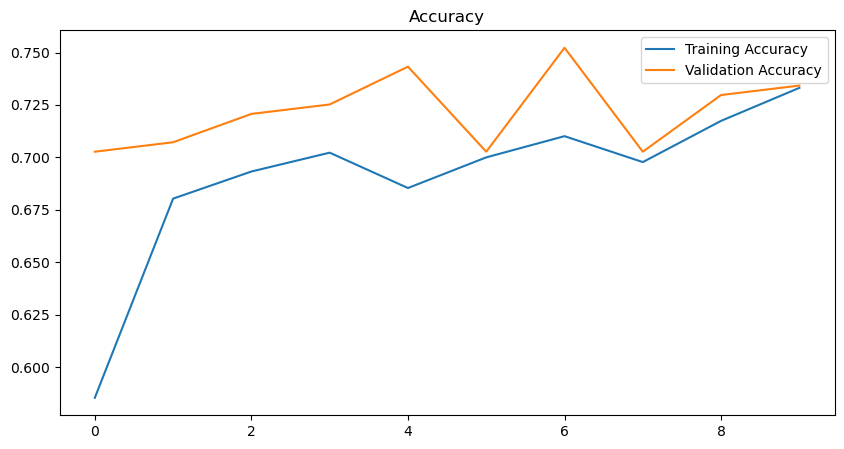

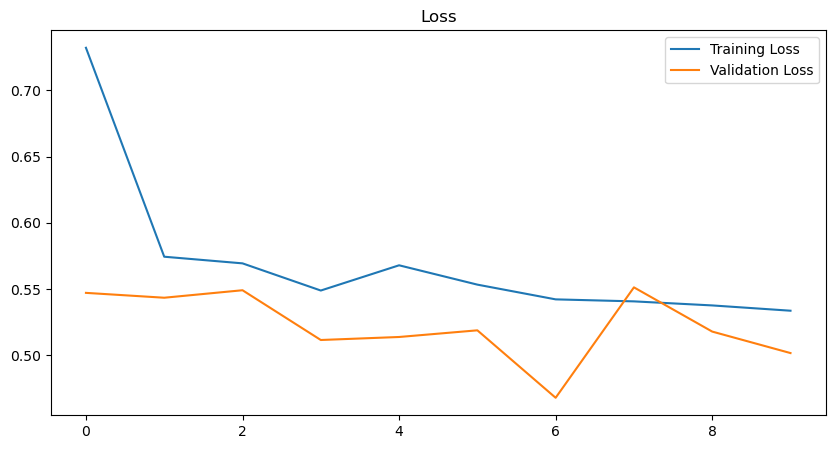

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# Data Generators
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "Skin Cancer Binary Split/train",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    "Skin Cancer Binary Split/val",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_test_datagen.flow_from_directory(
    "Skin Cancer Binary Split/test",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# CNN Model
model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    callbacks=[early_stop]
)

# Evaluate
test_loss, test_accuracy = model.evaluate(test_generator)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

# Save Model
model.save("skin_cancer_model.h5")

print("\nModel saved successfully!")

# Accuracy Graph
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss Graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()